In [12]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 256
#L = 1. ## STILL BAD...
#L = N
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

In [13]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1*dk,)))
energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))
specs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, lenn=phys_dims)
    specs.append((kD, fekD))
    e_parsevals = np.sum(fekD) * (dk/twopi)**D / np.sum(np.ones_like(f) * dx**D)
    assert np.isclose(e_parsevals / energies[i], 1., rtol=0.001), e_parsevals / energies[i]

## TODO: TEST VIA AUTOCORRELATION FUNCTION TOO

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:73: RuntimeWarning: divide by zero encountered in reciprocal
  terms.append((xx/bb[0])**(-a[0]))
/home/m/Documents/science_codes/Kea/Kea/simulator/fbm.py:62: RuntimeWarning: invalid value encountered in multiply
  output = np.sqrt(output * C)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:73: RuntimeWarning: divide by zero encountered in power
  terms.append((xx/bb[0])**(-a[0]))


In [14]:
from scipy.stats import binned_statistic

def kern(bins, D):
    if D == 1:
        return 2.
    if D == 2:
        return 2. * np.pi * bins
    if D == 3:
        return 4. * np.pi * bins**2

def get_bins(min_bin, max_bin, nbins, max_half_bin_width=None, log_space=False):
    if log_space:
        bin_range = np.exp(np.linspace(np.log(min_bin), np.log(max_bin), nbins+1))
    else:
        bin_range = np.linspace(min_bin, max_bin, nbins+1)

    ## NOTE: Inherited code converts to integers; there are probably problems
    ##        with doing this... and also not doing this...
    ## valid_bins = np.unique(bin_range.astype(int))
    valid_bins = np.unique(bin_range.round(decimals=4))

    lower_bins, upper_bins = valid_bins[:-1], valid_bins[1:]

    bin_width = (upper_bins - lower_bins) / 2.
    if max_half_bin_width is not None:
        bin_width = np.minimum(bin_width, max_half_bin_width)

    bins = upper_bins - bin_width
    # consequences of not using the above note
    bin_edges = np.unique(np.concatenate((bins-bin_width, bins+bin_width)).round(decimals=4))
    return bins, bin_width, bin_edges

def wrap_sum(d, l, n):
    def sum(x):
        return np.nansum(x) * (l/n)**(d-1) #/ (L/np.sum(np.isfinite(x)))**D
    return sum

def bin_data(nar, ar, mean_func='mean', std_func=np.nanstd,
             cut_excess=False, nan_small=False, min_bin=None,
             max_bin=None, bin_center=True, norm_bin_size=False, log_space=False,
             num_bins=None, ignore_nan=False, max_half_bin_width=None):
    # Find the basis of the position array
    pos = np.where(nar == 0)
    basis_index = [pos[i][0] for i in range(len(pos))]
    basis_index[0] = Ellipsis
    narbasis = nar[tuple(basis_index)]
    nn = narbasis[pos[0][0]:]

    # Calculate the bin space
    # Assume that the array is evenly space (this is an assumption made with everything)
    if min_bin is None:
        # If no minimum bin specified, then automatically choose one
        min_bin = np.nanmin(nn)

    if max_bin is None:
        max_bin = np.nanmax(nar)
    if isinstance(max_bin, str) and max_bin == 'basis':
        max_bin = np.nanmax(narbasis)

    if num_bins is None:
        binsize = np.diff(nn)[0]
        nbins = int(np.round(max_bin/binsize) + 1)
    else:
        nbins = num_bins

    bins, bin_widths, be = get_bins(min_bin, max_bin, nbins, max_half_bin_width, log_space)

    # Set bad, the regions outside the binning domain because scipy includes them into the binnings
    car = ar.copy()
    car[nar < min_bin] = np.nan
    car[nar > max_bin] = np.nan

    if mean_func == np.nansum:
        mean_func = wrap_sum(D, 2.*np.pi, L)
        #mean_func = np.nansum

    # Compute the binnings
    ar1d, bin_edges, _ = binned_statistic(nar.ravel(), car.ravel(), bins=be, statistic=mean_func)
    std1d, _, _ = binned_statistic(nar.ravel(), car.ravel(), bins=be, statistic=std_func)

    if nan_small:
        # Compute the counts, so we can ignore bad statistics
        cts, _, _ = binned_statistic(nar.ravel(), car.ravel(), bins=be, statistic='count')
        mask = cts <= 1
        ar1d[mask] = np.nan
        std1d[mask] = np.nan

    if bin_center:
       # Set the bins to the mid point of the bin edges
       bins1d = (bin_edges[1:] + bin_edges[:-1])/2.
    else:
       # Set the bins to the start of the bin edges
       bins1d = bin_edges[:-1]

    # if mean_func == np.nanmean:
    #     ar1d /= kern(bins1d, ar.ndim)

    if max_half_bin_width is not None:
        # We should remove the bad bin edges (for the bins we don't want)
        mask = np.isin(bins1d, bins)
        ar1d = ar1d[mask]
        std1d = std1d[mask]
        bins1d = bins1d[mask]

    # Divide the functions by their bin sizes
    # NOTE: The bin widths are actually half the bin widths
    if max_half_bin_width:
        # We have already calculate this
        width = 2.*bin_widths
    else:
        # Otherwise, calculate from binned_statistic bin_edges
        lower_bins, upper_bins = bin_edges[:-1], bin_edges[1:]
        width = (upper_bins - lower_bins)
        if max_half_bin_width is not None:
            width = np.minimum(width, 2.*max_half_bin_width)

    if norm_bin_size:
        ar1d = ar1d / width
        std1d = std1d / width

    if cut_excess:
        # Cut off lags above the basis directions
        ar1d = ar1d[bins1d <= nn[-1]]
        std1d = std1d[bins1d <= nn[-1]]
        width = width[bins1d <= nn[-1]]
        bins1d = bins1d[bins1d <= nn[-1]]

    if ignore_nan:
        # Remove nan values
        mask = np.isfinite(ar1d)
        ar1d = ar1d[mask]
        std1d = std1d[mask]
        width = width[mask]
        bins1d = bins1d[mask]

    return bins1d, ar1d, width


/tmp/ipykernel_14104/811626528.py:11: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(alphas[e], e_estimation / energies[e], marker='x', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872:

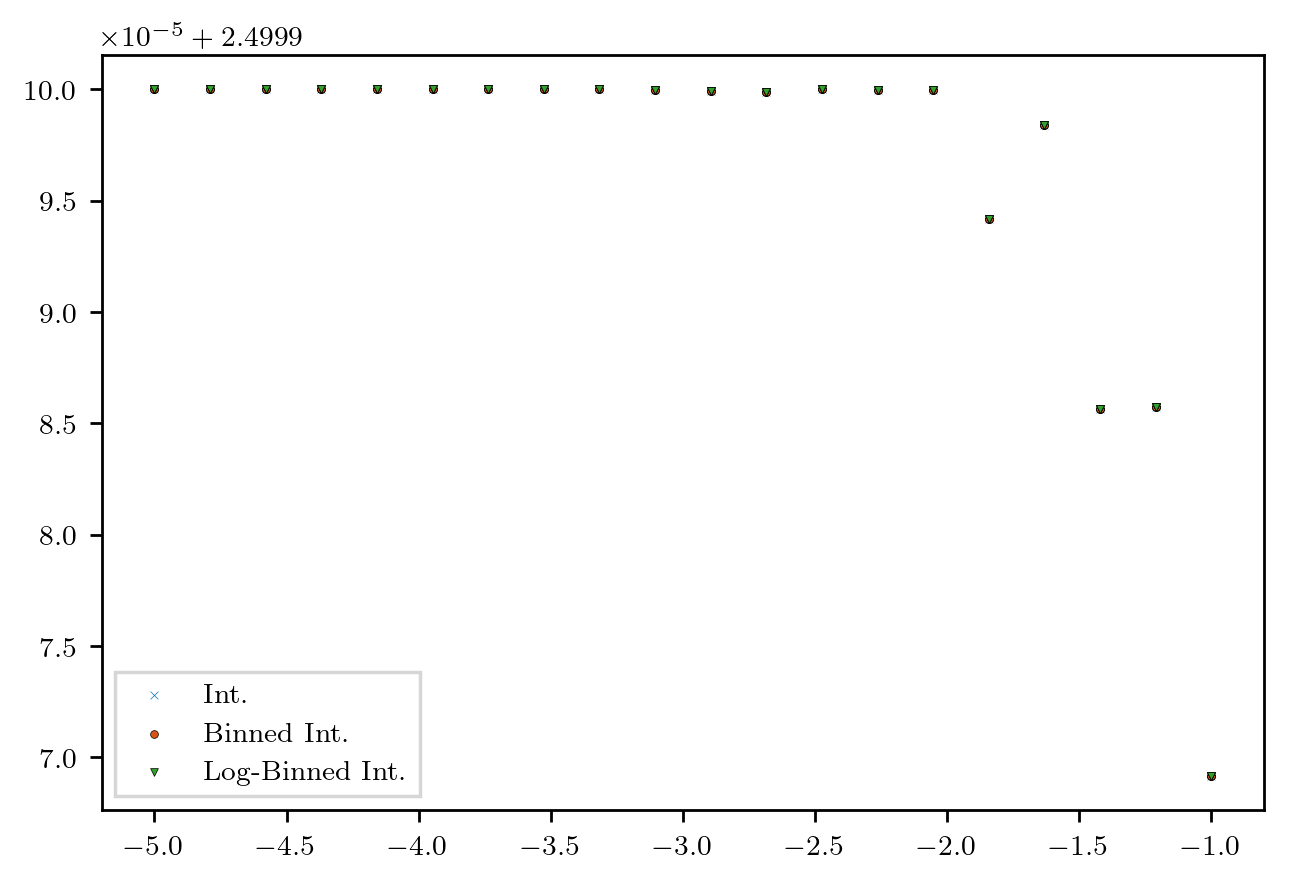

In [15]:
c = plotting.COLOR_CYCLE_6

for e, kfek in enumerate(specs):
    kD, fekD = kfek
    ko, feko, width = bin_data(spectra_base.wavenumber_mesh(kD), fekD,
        mean_func=np.nansum, min_bin=0., max_bin=None,
        ignore_nan=False, norm_bin_size=True, bin_center=True,
        cut_excess=False, nan_small=False)
    e_estimation = (1./twopi)**D * np.nansum(feko * width) / np.sum(np.ones(grid_dims) * dx**D)
    #print(e_estimation / energies[e])
    plt.scatter(alphas[e], e_estimation / energies[e], marker='x', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    #assert np.isclose(e_estimation / energies[e], 1., rtol=0.02), e_estimation / energies[e]

    for i in range(4, 8):
        ko, feko, width = bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            mean_func=np.nansum, min_bin=0., max_bin=None,
            ignore_nan=False, norm_bin_size=True, bin_center=True,
            cut_excess=False, nan_small=False, num_bins=N//i)
        e_estimation = (1./twopi)**D * np.nansum(feko * width) / np.sum(np.ones(grid_dims) * dx**D)
        #print(e_estimation / energies[e])
        plt.scatter(alphas[e], e_estimation / energies[e], marker='o', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')
        #assert np.isclose(e_estimation / energies[e], 1., rtol=0.02), e_estimation / energies[e]

    for i in range(4, 8):
        ko, feko, width = bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            mean_func=np.nansum, min_bin=2.*np.pi/L, max_bin=None,
            ignore_nan=False, norm_bin_size=True, bin_center=True,
            cut_excess=False, nan_small=False, num_bins=N//i, log_space=True)
        e_estimation = (1./twopi)**D * np.nansum(feko * width) / np.sum(np.ones(grid_dims) * dx**D)
        #print(e_estimation / energies[e])
        plt.scatter(alphas[e], e_estimation / energies[e], marker='v', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')
        #assert np.isclose(e_estimation / energies[e], 1., rtol=0.02), e_estimation / energies[e]

plt.scatter([], [], marker='x', s=5., color=c[0], linewidth=0.2, edgecolor='black', label=r'Int.')
plt.scatter([], [], marker='o', s=5., color=c[1], linewidth=0.2, edgecolor='black', label=r'Binned Int.')
plt.scatter([], [], marker='v', s=5., color=c[2], linewidth=0.2, edgecolor='black', label=r'Log-Binned Int.')
plt.legend(fancybox=False, frameon=True)

/tmp/ipykernel_14104/353083083.py:15: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(alphas[e], e_estimation / energies[e], marker='x', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = 

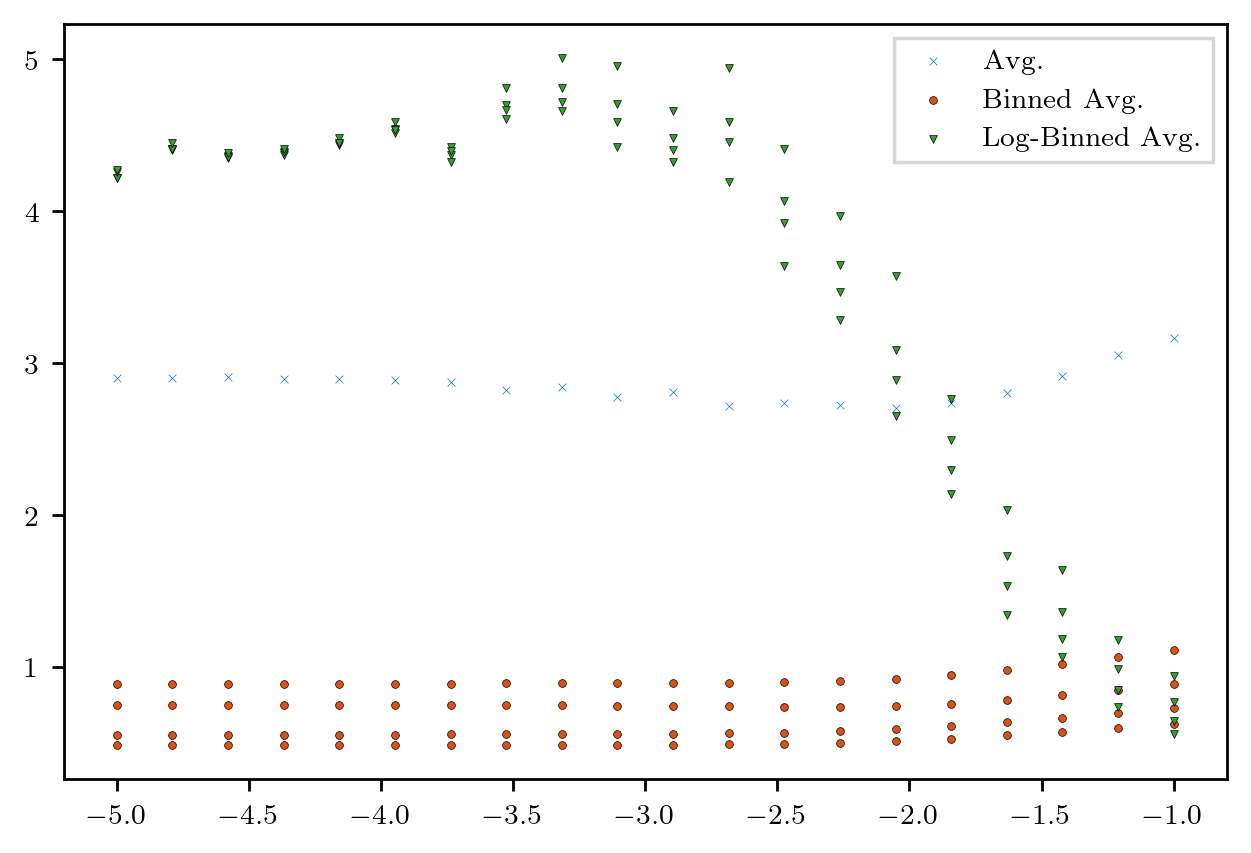

In [17]:

for e, kfek in enumerate(specs):
    kD, fekD = kfek
    km, fekm, width = bin_data(spectra_base.wavenumber_mesh(kD), fekD,
                        mean_func=np.nanmean, min_bin=0., max_bin=None,
                        ignore_nan=False, norm_bin_size=True, bin_center=True,
                        cut_excess=False, nan_small=False)
    if D == 1:
        dOmega = 2.
    if D == 2:
        dOmega = 2. * np.pi * km
    if D == 3:
        dOmega = 4. * np.pi * km**2
    e_estimation = np.nansum(fekm * dOmega * width) * (1./twopi)**D / np.sum(np.ones(grid_dims) * dx**D)
    #print(e_estimation / energies[e])
    plt.scatter(alphas[e], e_estimation / energies[e], marker='x', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    #assert np.isclose(np.nansum(fekm * width * dOmega) * (1./twopi)**D / energies[e], 1., rtol=0.001)

    for i in range(4, 8):
        km, fekm, width = bin_data(spectra_base.wavenumber_mesh(kD), fekD,
                mean_func=np.nanmean, min_bin=0., max_bin=None,
                ignore_nan=False, norm_bin_size=True, bin_center=True,
                cut_excess=False, nan_small=False, num_bins=N//i)
        if D == 1:
            dOmega = 2.
        if D == 2:
            dOmega = 2. * np.pi * km
        if D == 3:
            dOmega = 4. * np.pi * km**2
        e_estimation = np.nansum(fekm * dOmega * width) * (1./twopi)**D / np.sum(np.ones(grid_dims) * dx**D)
        #print(e_estimation / energies[e])
        plt.scatter(alphas[e], e_estimation / energies[e], marker='o', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')
        #assert np.isclose(np.nansum(fekm * width * dOmega) * (1./twopi)**D / energies[e], 1., rtol=0.001)

    for i in range(4, 8):
        km, fekm, width = bin_data(spectra_base.wavenumber_mesh(kD), fekD,
                        mean_func=np.nanmean, min_bin=2.*np.pi/L, max_bin=None,
                        ignore_nan=False, norm_bin_size=True, bin_center=True,
                        cut_excess=False, nan_small=False, num_bins=N//i, log_space=True)
        if D == 1:
            dOmega = 2.
        if D == 2:
            dOmega = 2. * np.pi * km
        if D == 3:
            dOmega = 4. * np.pi * km**2
        e_estimation = np.nansum(fekm * dOmega * width) * (1./twopi)**D / np.sum(np.ones(grid_dims) * dx**D)
        #print(e_estimation / energies[e])
        plt.scatter(alphas[e], e_estimation / energies[e], marker='v', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')
        #assert np.isclose(np.nansum(fekm * width * dOmega) * (1./twopi)**D / energies[e], 1., rtol=0.001)

plt.scatter([], [], marker='x', s=5., color=c[0], linewidth=0.2, edgecolor='black', label=r'Avg.')
plt.scatter([], [], marker='o', s=5., color=c[1], linewidth=0.2, edgecolor='black', label=r'Binned Avg.')
plt.scatter([], [], marker='v', s=5., color=c[2], linewidth=0.2, edgecolor='black', label=r'Log-Binned Avg.')
plt.legend(fancybox=False, frameon=True)
